In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import csv
from functools import reduce
from sklearn.decomposition import PCA

In [2]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [3]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [4]:
event1='new_best_5sec'
# event2='best'
n_clusters=500
label_files=[]
cluster_files=[]
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files.append(file)
    elif f'_{n_clusters}_' in file and 'clusters' in file and event1 in file:
        cluster_files.append(file)

## Load supervox

In [5]:
cluster_files

['superclust_clusters_500_new_best_5sec.pkl']

In [6]:
%%time
best_cluster_path_5sec=os.path.join(cluster_dir,cluster_files[0])
# best_cluster_path=os.path.join(cluster_dir,cluster_files[1])
print(best_cluster_path_5sec)
with open(best_cluster_path_5sec, 'rb') as file:
    five_sec = pickle.load(file)
    print(five_sec.keys())

# with open(best_cluster_path, 'rb') as file:
#     best = pickle.load(file)
#     print(best.keys())
    

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/superclust_clusters_500_new_best_5sec.pkl
dict_keys(['inc', 'dec', 'flat', 'non'])
CPU times: user 1.07 ms, sys: 1.12 ms, total: 2.19 ms
Wall time: 25.2 ms


In [7]:
label_files

['supercluster_labels_total_500.npy']

In [8]:
%%time
best_label_path=os.path.join(cluster_dir,label_files[0])
print(best_label_path)
giant_total_labels=np.load(best_label_path)
print(giant_total_labels.shape)

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/supercluster_labels_total_500.npy
(4171804,)
CPU times: user 3.14 ms, sys: 21.4 ms, total: 24.5 ms
Wall time: 229 ms


In [9]:
giant_total_anat=giant_total_labels.reshape(314,146,91)


In [10]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25']) #,  '#6d0d25'
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [11]:
giant_total_anat.shape

(314, 146, 91)

In [12]:
fixed = brainsss.load_fda_meanbrain()
behaviors=list(five_sec.keys())

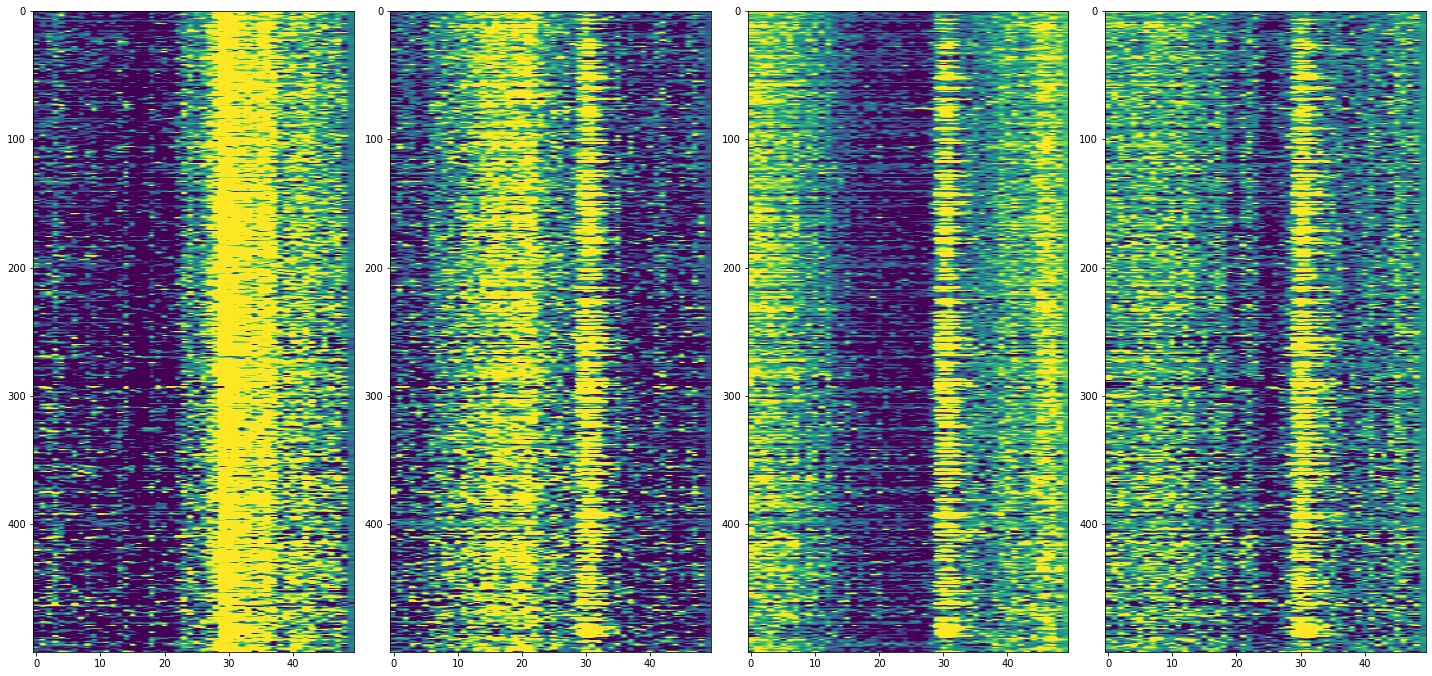

In [13]:
# ax_ap=0.1
# superclust_dict=best
# fig,axs=plt.subplots(1,3,figsize=(10,10))
# axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
# axs[0].set_aspect(ax_ap)
# axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
# axs[1].set_aspect(ax_ap)
# axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
# axs[2].set_aspect(ax_ap)
# plt.tight_layout()

ax_ap=0.2
start=15
end=40
superclust_dict=five_sec
fig,axs=plt.subplots(1,4,figsize=(20,10))
axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
axs[0].set_aspect(ax_ap)
axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
axs[1].set_aspect(ax_ap)
axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
axs[2].set_aspect(ax_ap)
axs[3].imshow(superclust_dict['non'],  vmax=0.01,vmin=-0.01)
axs[3].set_aspect(ax_ap)
plt.tight_layout()

In [14]:
# superclust_dict_z={}
# for behavior in best:
#     print(behavior)
#     signals_total_z=scipy.stats.zscore(best[behavior],axis=1)
#     superclust_dict_z[behavior]=signals_total_z
    
superclust_dict_z={}
for behavior in five_sec:
    print(behavior)
    signals_total_z=scipy.stats.zscore(five_sec[behavior][:,14:41],axis=1)
    superclust_dict_z[behavior]=signals_total_z

inc
dec
flat
non


In [15]:
superclust_dict_z.keys()

dict_keys(['inc', 'dec', 'flat', 'non'])

In [16]:
file_path=os.path.join(cluster_dir, 'individual_fly_superclusters_2bin_total.pkl')
with open(file_path, 'rb') as file:
        fly_superclust_dict = pickle.load(file)

In [17]:
fly_num=[226,227,228,234,239,240,241,242,249,250]
for fn in fly_num:
    behave_dic=fly_superclust_dict['flat']
    if fn in list(behave_dic.keys()):
        print(np.count_nonzero(~np.isnan(behave_dic[fn][...,0])))

3792
70427
23236
30791
6494
7184
8987
10336
51395
54942


In [18]:
fly_superclust_dict['inc'].keys()

dict_keys([226, 228, 234, 239, 240, 241, 242, 249, 250])

In [19]:
num_vox=[]
for behave in fly_superclust_dict:
    for fly in fly_superclust_dict[behave]:
        count_vox=np.shape(fly_superclust_dict[behave][fly])[-2]
        num_vox.append(count_vox)
max_val=np.max(num_vox)
print(max_val)

1350


In [20]:
for behave in fly_superclust_dict:
    for fly in fly_superclust_dict[behave]:
        count_vox=np.shape(fly_superclust_dict[behave][fly])[-2]
        if count_vox<max_val:
            pad_val=max_val-count_vox
#             print(pad_val)
            matrix=fly_superclust_dict[behave][fly]
            padded_matrix = np.pad(matrix, ((0, 0), (0, pad_val),(0,0)),'constant', constant_values=np.nan)
            fly_superclust_dict[behave][fly]=padded_matrix 

In [21]:
intervals=np.asarray([[0,7],[12,19]])
downsampled_superclust_dict={}
clust_dict=superclust_dict_z
for behave in clust_dict:
    cluster_dict=np.asarray(clust_dict[behave])
    downsampled_superclust=[]
    for interval in intervals:
        start=interval[0]
        end=interval[1]
#         print(start-end)
        avg_time=np.mean(cluster_dict[:,start:end],axis=-1)
        downsampled_superclust.append(avg_time)
        start=end
    downsampled_superclust=np.asarray(downsampled_superclust).T
#     print(np.shape(downsampled_superclust))
    downsampled_superclust_dict[behave]=downsampled_superclust

In [22]:
%%time
anova_dict={}
for behave in fly_superclust_dict:
    anova_dict[behave]={}
    avg_clusts=downsampled_superclust_dict[behave]
    individual_clusts=fly_superclust_dict[behave]
    for i,super_clust in enumerate(avg_clusts):
        anova_dict[behave][i]=[]
        for v, tp in enumerate(super_clust):
            ind_clus=[]
            for fly in individual_clusts:
                ind_clus_nan=individual_clusts[fly][i,:,v]
#                 print(ind_clus_nan)
#                 if np.all(np.isnan(ind_clus_nan))==False:
                ind_clus=np.concatenate((ind_clus,ind_clus_nan))

            anova_dict[behave][i].append(np.asarray(ind_clus))
        anova_dict[behave][i]=np.asarray(anova_dict[behave][i])
#         print(np.shape(anova_dict[behave][i]))

CPU times: user 173 ms, sys: 74.8 ms, total: 248 ms
Wall time: 248 ms


In [23]:
anova_dict['inc'][499].shape

(2, 12150)

In [24]:
dic=anova_dict
bs=np.asarray(list(dic.keys()))
combos=list(itertools.combinations(bs, 2))
print(combos)

[('inc', 'dec'), ('inc', 'flat'), ('inc', 'non'), ('dec', 'flat'), ('dec', 'non'), ('flat', 'non')]


In [25]:
def columnwise_mannwhitney(a, b):
    """
    Performs Mann-Whitney U test on each column separately
    a, b: arrays of shape (n_samples, n_features)
    Returns: arrays of statistics and p-values for each column
    """
    a = np.array(a)
    b = np.array(b)
    
    n_cols = a.shape[1]
    stats = []
    p_vals = []
    
    for col in range(n_cols):
        # Get data for this column
        a_col = a[:, col]
        b_col = b[:, col]
        
        # Remove NaNs
        a_clean = a_col[~np.isnan(a_col)]
        b_clean = b_col[~np.isnan(b_col)]
        
        if len(a_clean) < 1 or len(b_clean) < 1:
            stats.append(np.nan)
            p_vals.append(np.nan)
        else:
            try:
                stat, p_val = scipy.stats.mannwhitneyu(a_clean, b_clean)
                stats.append(stat)
                p_vals.append(p_val)
            except:
                stats.append(np.nan)
                p_vals.append(np.nan)
    
    return np.array(stats), np.array(p_vals)

In [26]:
pval_dict={}
for c in combos:
    b_1=c[0]
    b_2=c[1]
    new_key=f'{b_1}_vs_{b_2}'
    temp=[]
    for clust in range(500):
        a=np.moveaxis(anova_dict[b_1][clust],0,-1)
#         print(np.shape(a))
        b=np.moveaxis(anova_dict[b_2][clust],0,-1)
#         print(np.shape(b))
#         tstat,p_val=scipy.stats.ttest_ind(a,b,axis=-1,nan_policy='omit')
        stat,p_val=columnwise_mannwhitney(a,b)
#         print(p_val)
        temp.append(list(p_val))
    pval_dict[new_key]=temp

In [27]:
pval_dict.keys()

dict_keys(['inc_vs_dec', 'inc_vs_flat', 'inc_vs_non', 'dec_vs_flat', 'dec_vs_non', 'flat_vs_non'])

In [28]:
pval_correct_dict={}
for key in pval_dict:
    pval_flat=np.asarray(pval_dict[key]).flatten()
    rejected, p_corrected, alpha_sidak, alpha_bonf = multipletests(pval_flat, alpha=0.01, method='bonferroni')
    pval_correct=p_corrected.reshape(*np.shape(pval_dict[key]))
    pval_correct_dict[key]=pval_correct

In [29]:
k='flat_vs_non'
# custom_labels = [''] * len(pval_correct_dict[k])  # Start with all empty strings
# custom_labels[281] = 'Here!!!'  # Set label at desired position

<AxesSubplot:>

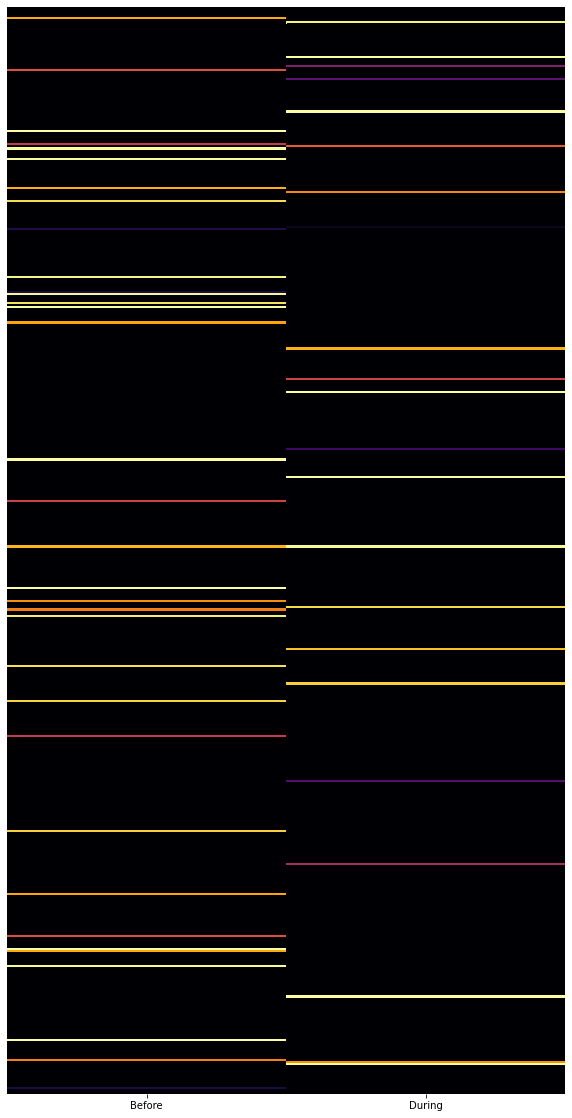

In [30]:
fig, ax = plt.subplots(figsize=(10, 20))  # Tall and narrow for 500x5
sns.heatmap(pval_correct_dict[k], 
            cmap='inferno_r', 
            ax=ax,yticklabels=False, cbar=False,
            xticklabels=['Before','During'],vmax=0.01)
# cbar = fig.colorbar(ax.collections[0], ax=ax)
# cbar.set_label('p-val', rotation=270, labelpad=20)
# cbar.outline.set_visible(False)
# ax.axhline(y=281,ls='--', color='g', lw=2)
# cbar.set_ticks([vmax, 0, vmin]) 
# ax.axhline(y=379, color='w', lw=2)
# plt.savefig(os.path.join(save_dir,f'p_vals_{b_1}_{b_2}.png'), dpi=300, bbox_inches='tight')

In [31]:
best_clus_dict={}
for ki in pval_correct_dict:
    print(ki)
    best_clus=[]
    for i,clus in enumerate(pval_correct_dict[ki]):
        if clus[0]<0.01:
            best_clus.append(i)
    print(best_clus)
    print(len(best_clus))
    best_clus_dict[ki]=best_clus

inc_vs_dec
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 19, 20, 21, 22, 23, 24, 26, 29, 30, 31, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 47, 48, 50, 51, 52, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 70, 72, 73, 74, 75, 78, 79, 80, 81, 82, 85, 86, 87, 88, 89, 90, 91, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 108, 109, 111, 113, 115, 116, 117, 119, 120, 122, 123, 124, 125, 127, 128, 129, 130, 131, 132, 133, 135, 136, 137, 138, 139, 140, 142, 143, 145, 146, 147, 148, 149, 151, 152, 153, 154, 155, 156, 157, 159, 160, 162, 163, 164, 165, 166, 167, 168, 169, 170, 172, 173, 174, 175, 177, 178, 180, 181, 182, 184, 185, 186, 187, 188, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 203, 204, 205, 206, 207, 208, 210, 211, 212, 213, 214, 215, 216, 219, 220, 221, 222, 223, 224, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 239, 240, 241, 242, 243, 244, 245, 246, 248, 249, 252, 259, 261, 264, 265, 267, 270, 271, 272, 273, 275, 276

In [32]:
list(pval_dict.keys())

['inc_vs_dec',
 'inc_vs_flat',
 'inc_vs_non',
 'dec_vs_flat',
 'dec_vs_non',
 'flat_vs_non']

In [33]:
same_before=[]
same_during=[]
same=[]
pvals=pval_correct_dict
for i in range(np.shape(list(pvals.values()))[1]):
    keys=np.asarray(list(pvals.keys()))
    ar_1=pvals[keys[0]][i]
    ar_2=pvals[keys[1]][i]
    ar_3=pvals[keys[2]][i]
    ar_4=pvals[keys[3]][i]
    ar_5=pvals[keys[4]][i]
    ar_6=pvals[keys[5]][i]

    if ar_1[0]>0.01 and ar_2[0]>0.01 and ar_3[0]>0.01 and ar_4[0]>0.01 and ar_5[0]>0.01 and ar_6[0]>0.01 and ar_1[1]>0.01 and ar_2[1]>0.01 and ar_3[1]>0.01 and ar_4[1]>0.01 and ar_5[1]>0.01 and ar_6[1]>0.01:
#     if ar_1[0]>0.01 and ar_2[0]>0.01 and ar_4[0]>0.01 and ar_1[1]>0.01 and ar_2[1]>0.01 and ar_4[1]>0.01:
        same.append(i)
same_before=np.asarray(same_before)
same_during=np.asarray(same_during)
same=np.asarray(same)

In [34]:
same.shape

(70,)

In [35]:
old_same=np.asarray([ 43,  49,  60,  69,  76,  78,  84, 106, 107, 110, 114, 121, 130,
       141, 144, 150, 161, 171, 176, 179, 184, 200, 217, 223, 246, 247,
       254, 258, 260, 262, 269, 274, 293, 296, 297, 301, 302, 308, 309,
       313, 325, 327, 331, 338, 340, 342, 346, 347, 355, 357, 359, 366,
       367, 371, 373, 375, 391, 392, 393, 396, 400, 405, 409, 410, 412,
       413, 415, 418, 420, 429, 430, 444, 447, 449, 457, 459, 463, 468,
       472, 473, 477, 479, 483, 485, 487, 491, 493, 494, 499])

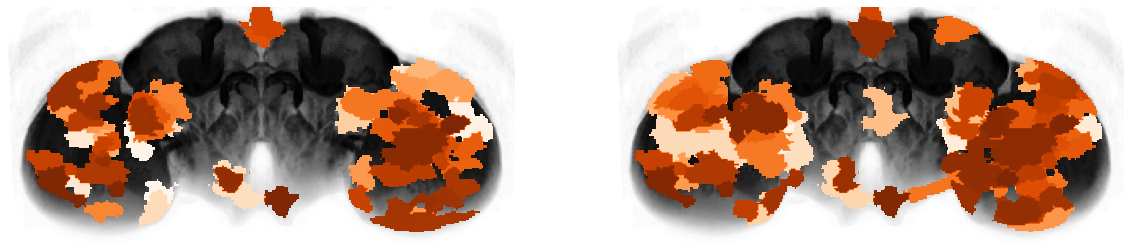

In [36]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
labels_anat_sub_total_new=np.where(np.isin(giant_labels_anat,same),giant_labels_anat,np.nan)
labels_anat_sub_total_old=np.where(np.isin(giant_labels_anat,old_same),giant_labels_anat,np.nan)
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
fig,ax=plt.subplots(1,2,figsize=(20,10))
ax[0].imshow(np.max(fixed.numpy(), axis=-1).T,cmap='gray_r');
ax[0].imshow(np.nanmax(labels_anat_sub_total_new,axis=-1).T,cmap='Oranges');
# plt.imshow(np.swapaxes(edges_,0,1)*10000);
ax[0].axis('off');
ax[1].imshow(np.max(fixed.numpy(), axis=-1).T,cmap='gray_r');
ax[1].imshow(np.nanmax(labels_anat_sub_total_old,axis=-1).T,cmap='Oranges');
# plt.imshow(np.swapaxes(edges_,0,1)*10000);
ax[1].axis('off');
# plt.savefig(os.path.join(save_dir,f'p_vals_map_nonsig.png'), dpi=300, bbox_inches='tight')

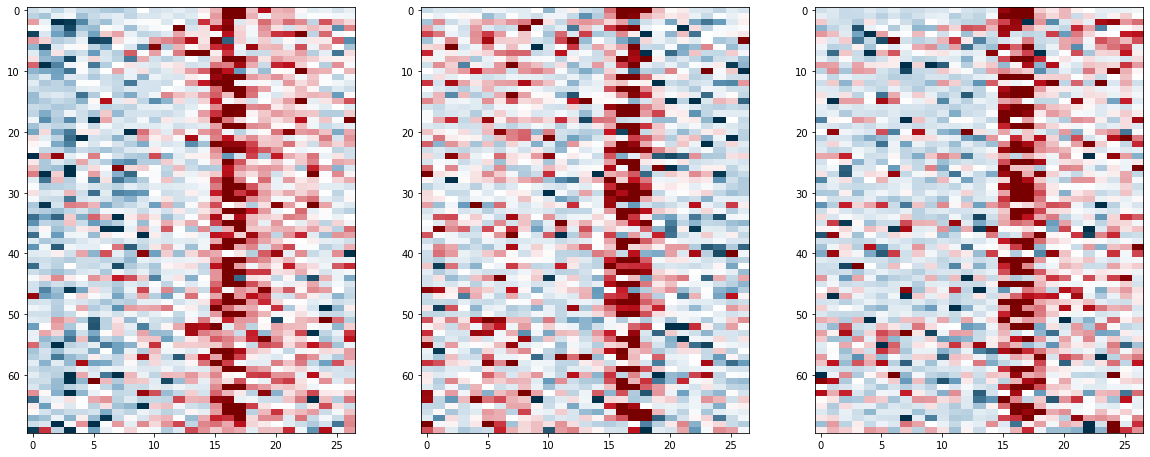

In [37]:
ax_ap=0.5
vmax=2
vmin=-2
# not_in=~np.isin(np.arange(500),rois)
fig,ax=plt.subplots(1,3,figsize=(20,10))
b='inc'
ax[0].imshow(superclust_dict_z[b][same,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_aspect(ax_ap)
b='dec'
ax[1].imshow(superclust_dict_z[b][same,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
b='flat'
ax[2].imshow(superclust_dict_z[b][same,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)

In [38]:
old_same=[ 43,  49,  60,  69,  76,  78,  84, 106, 107, 110, 114, 121, 130,
       141, 144, 150, 161, 171, 176, 179, 184, 200, 217, 223, 246, 247,
       254, 258, 260, 262, 269, 274, 293, 296, 297, 301, 302, 308, 309,
       313, 325, 327, 331, 338, 340, 342, 346, 347, 355, 357, 359, 366,
       367, 371, 373, 375, 391, 392, 393, 396, 400, 405, 409, 410, 412,
       413, 415, 418, 420, 429, 430, 444, 447, 449, 457, 459, 463, 468,
       472, 473, 477, 479, 483, 485, 487, 491, 493, 494, 499]
new_same=same

In [39]:
best_total=[old_same,new_same]
common_values=reduce(np.intersect1d, best_total)
print(np.shape(old_same),np.shape(new_same),np.shape(common_values))

(89,) (70,) (44,)


In [40]:
reg=np.arange(500)
without=reg[~np.isin(reg,new_same)]

In [41]:
without[without==8]=without[-1]
without=np.unique(without)

In [42]:
superclust_labels_dict={}
for behave in superclust_dict_z:
    temp_shape=superclust_dict_z[behave].shape
    superclust_labels_dict[behave]=np.full(temp_shape[0],behave)

In [43]:
behaviored_superclust={}
behaviored_labels={}

for behave in superclust_dict_z:
    behaviored_superclust[behave]=superclust_dict_z[behave][without,:]
    behaviored_labels[behave]=superclust_labels_dict[behave][without]

In [44]:
print(behaviored_superclust['dec'].shape)
print(behaviored_labels['dec'].shape)

(429, 27)
(429,)


In [45]:
og_clust=np.arange(500)[without]
og_clust.shape
# og_clust.max()

(429,)

In [46]:
og_clust[428]

499

In [47]:
dict_tolook=behaviored_superclust
behaviored_giant_superclust={'clus':[], 'labels':[], 'origin':[]}
for i in range(dict_tolook['inc'].shape[0]):
#     print(i)
    clust_behave=np.vstack((dict_tolook['inc'][i,:],dict_tolook['dec'][i,:],dict_tolook['flat'][i,:],dict_tolook['non'][i,:]))
    clust_labels=np.vstack((superclust_labels_dict['inc'][i],superclust_labels_dict['dec'][i],superclust_labels_dict['flat'][i],superclust_labels_dict['non'][i]))
#     og_clust=np.arange(500)
    og_clust_temp=np.vstack((og_clust[i],og_clust[i],og_clust[i],og_clust[i]))
    behaviored_giant_superclust['clus'].append(clust_behave)
    behaviored_giant_superclust['labels'].append(clust_labels)
    behaviored_giant_superclust['origin'].append(og_clust_temp)

behaviored_giant_superclust['clus']=np.vstack(behaviored_giant_superclust['clus'])
print(behaviored_giant_superclust['clus'].shape)
behaviored_giant_superclust['labels']=np.vstack(behaviored_giant_superclust['labels'])
print(behaviored_giant_superclust['labels'].shape)
behaviored_giant_superclust['origin']=np.vstack(behaviored_giant_superclust['origin'])
print(behaviored_giant_superclust['origin'].shape)

(1716, 27)
(1716, 1)
(1716, 1)


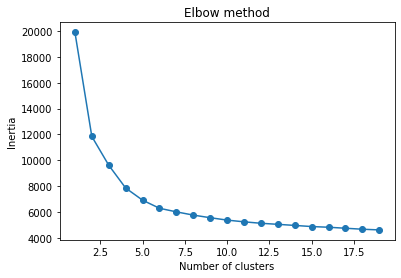

In [48]:
data=gaussian_filter1d(behaviored_giant_superclust['clus'],sigma=1)
# data=giant_superclust

inertias = []
ks = 20

for i in range(1,ks):
    kmeans = sklearn.cluster.KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,ks), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
# plt.savefig(os.path.join(save_dir,f'k_elbow_smooth.png'), dpi=300, bbox_inches='tight')
plt.show()

In [49]:
n_clusters=8
kmeans = sklearn.cluster.KMeans(n_clusters=n_clusters)
kmeans.fit(data)
np.shape(kmeans.labels_)

(1716,)

In [50]:
labels=kmeans.labels_
sort_array=np.argsort(labels)
k_clustered=data[sort_array]
# k_labels=behaviored_giant_superclust['labels'][sort_array]
# k_origins=behaviored_giant_superclust['origin'][sort_array]

In [51]:
np.max(behaviored_giant_superclust['origin'])

499

In [52]:
rainbow_color=np.asarray(['#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#a4036f', '#6d0d25']) 
rainbow_color=rainbow_color[:n_clusters]
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [53]:
np.shape(k_clustered)

(1716, 27)

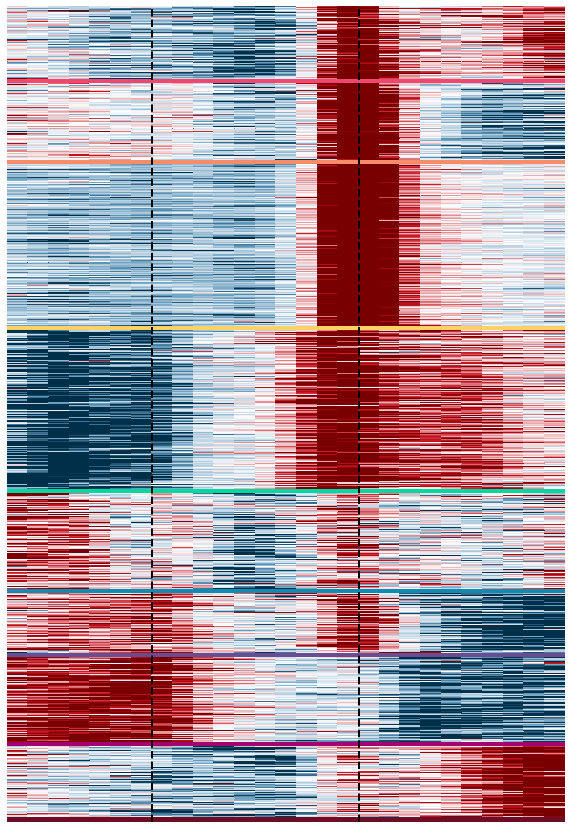

In [54]:
to_plot=k_clustered
color_map=rainbow_color
clustered=np.unique(labels)
vmax=1
vmin=-1
fig,axs=plt.subplots(figsize=(10,15))
sns.heatmap(to_plot,yticklabels=[],xticklabels=[],
            cmap=cmap_personal, cbar=False, ax=axs, center=0,vmax=vmax,vmin=vmin)
superclust_size=np.shape(to_plot)[0]
total=0
axs.axhline(y=np.shape(k_clustered)[0], color=color_map[-1], lw=10)
for cluss in clustered:
    clus_size=np.shape(labels[labels==cluss])[0]
    total+=clus_size
    if total<superclust_size:
        axs.axhline(y=(total), color=color_map[cluss], lw=4)
x1=7;x2=17
axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
# plt.savefig(os.path.join(save_dir,f'k_{n_clusters}clusters_smooth_without.png'), dpi=300, bbox_inches='tight')

In [55]:
dict_tolook['flat'].shape[0]
len(dict_tolook)

4

In [56]:
behaviored_giant_superclust['origin'].shape

(1716, 1)

In [57]:
types=np.zeros((500, len(dict_tolook)))
clus_info={}
for clus in clustered:
    clus_info[clus]={}
    clus_in=np.where(labels==clus)[0]
    clus_info[clus]['giant_clus']=clus_in
    clus_labels=np.asarray(behaviored_giant_superclust['labels'])[clus_in]
    clus_info[clus]['k_clus']=clus_labels
    clus_origins=np.asarray(behaviored_giant_superclust['origin'])[clus_in]
    clus_info[clus]['og_clus']=clus_origins
#     print(np.shape(clus_origins))

    for i,el in enumerate(clus_info[clus]['og_clus']):
        behave=clus_info[clus]['k_clus'][i]
        if behave=='flat':
            types[el,0]=clus
        elif behave=='inc':
            types[el,2]=clus
        elif behave=='dec':
            types[el,3]=clus
        elif behave=='non':
            types[el,1]=clus


In [58]:
print(clus_info[clus]['og_clus'].max())
print(types.shape)

498
(500, 4)


In [59]:
types=types[without]
print(types.shape)

(429, 4)


<AxesSubplot:>

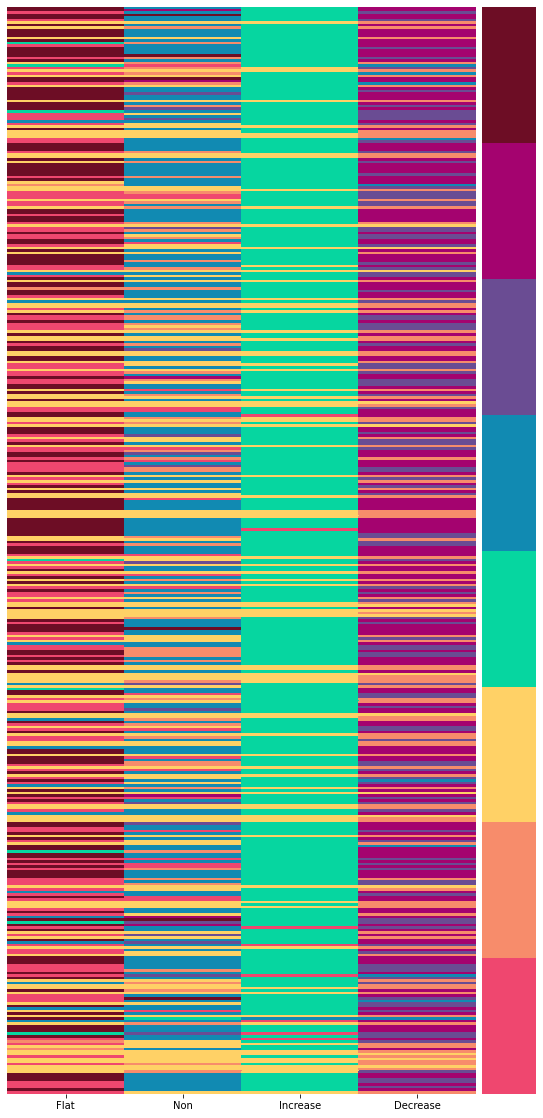

In [60]:
fig, ax = plt.subplots(figsize=(10, 20))  # Tall and narrow for 500x5
# custom_ticks=np.arange(1,(n_clusters+1))
# sns.set(font_scale=1)
sns.heatmap(types, 
            cmap=cmap_rainbow, 
            ax=ax,yticklabels=False, cbar=True,
            xticklabels=['Flat','Non','Increase','Decrease'], 
            cbar_kws={'ticks': [],"pad": 0.01})

# plt.savefig(os.path.join(save_dir,f'k_{n_clusters}types_smooth_without.png'), dpi=300, bbox_inches='tight')

In [61]:
clus_labels={}
for cluster in range(n_clusters):
#     clusters_4_look=np.where(labels==cluster)[0]
    clusters_4_look=clus_info[cluster]['og_clus']
    print(np.shape(clusters_4_look))
    uniques=np.unique(clusters_4_look)
# #     uniques[uniques==8]=uniques[-1]
#     behave_unqiues=without[uniques]
    print(np.shape(uniques))
    clus_labels[cluster]=uniques

(156, 1)
(137,)
(172, 1)
(155,)
(348, 1)
(144,)
(343, 1)
(336,)
(211, 1)
(195,)
(134, 1)
(128,)
(188, 1)
(182,)
(164, 1)
(159,)


In [62]:
red=['#EF476F', '#F58EA6', '#FAC7D3']
orange=['#F78C6B', '#FAB49E', '#FCD2C5']
yellow=['#FFD166', '#FFE099', '#FFEDC2']
green=['#06D6A0', '#24F9C1', '#74FBD7']
blue=['#118AB2', '#1FB7EA', '#7CD5F3']
purple=['#6A4C93','#9478BA', '#BFAED5']
pinkpurple=['#a4036f','#FA0FAC', '#FD87D5']
maroon=['#6d0d25','#802a3f', '#a16070']
color_dict={'0':red,'1':orange,'2':yellow,'3':green,'4':blue,'5':purple,'6':pinkpurple,'7':maroon}

In [63]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#727272'
}

flat (158,)
non (6,)


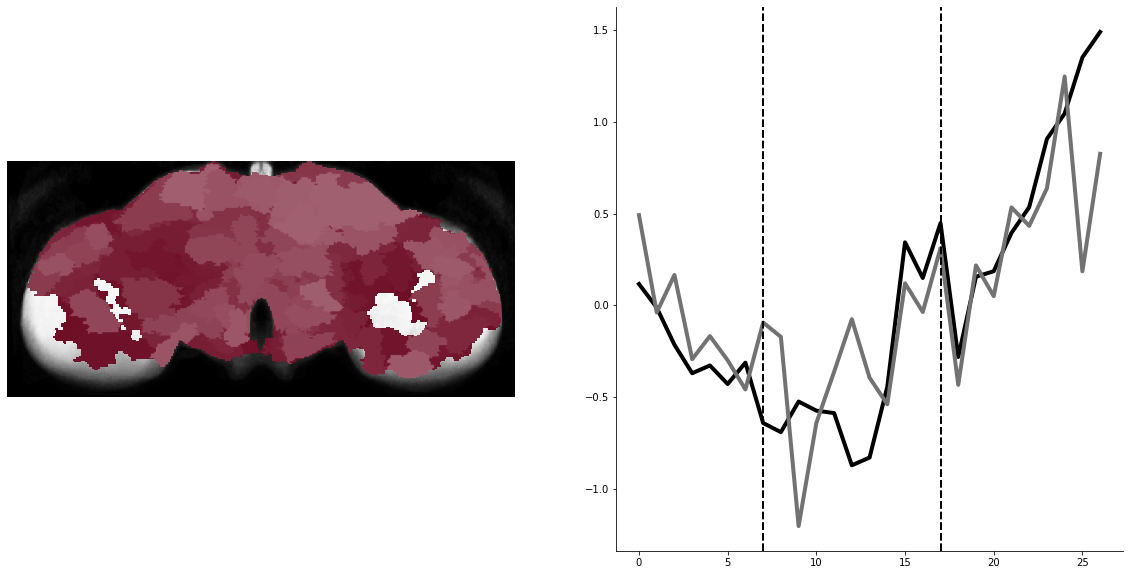

In [64]:
c=7
giant_labels_anat=giant_total_labels.reshape(314,146,91)
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,clus_labels[c]),giant_labels_anat,np.nan)
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
fig,ax=plt.subplots(1,2,figsize=(20,10))
ax[0].imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
cmap_single = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_dict[str(c)])
ax[0].imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=cmap_single)
ax[0].axis('off');
rois=clus_labels[c]
clus_in=np.where(labels==c)[0]
# print(np.shape(clus_in))
which=clus_info[c]['k_clus'][:,0]
# print(np.shape(which))
origin=clus_info[c]['og_clus'][:,0]
# print(np.shape(origin))
for behave in superclust_dict_z:
    behave_clusts=(which==behave)
    real_clus=origin[behave_clusts]
#     print(real_clus.shape)
    if real_clus is not [] and np.shape(real_clus)[0]>5:
        print(behave, np.shape(real_clus))
        temp=np.mean(superclust_dict_z[behave][real_clus],axis=0)
        ax[1].plot(temp,color=behavior_colors[behave], label=behave, lw=4)
        x1=7;x2=17
        ax[1].axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
        ax[1].axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
        ax[1].spines['top'].set_visible(False)
        ax[1].spines['right'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'k_{c}_areas_without.png'), dpi=300, bbox_inches='tight')

In [65]:
# fig,axs=plt.subplots(figsize=(10,10))
# rois=clus_labels[c]
# clus_in,which=which_behave(giant_labels_anat,c,superclust_dict_z)
# for behave in superclust_dict_z:
#     behave_clusts=clus_in[which==behave]
#     real_clus=np.floor(behave_clusts/4).astype(int)
#     if real_clus is not []:
#         temp=np.mean(superclust_dict_z[behave][real_clus],axis=0)
#         axs.plot(temp,color=behavior_colors[behave], label=behave, lw=4)
#         x1=6;x2=16
#         axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
#         axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
#         axs.spines['top'].set_visible(False)
#         axs.spines['right'].set_visible(False)
# #     axs.spines['bottom'].set_visible(False)
# #     axs.spines['left'].set_visible(False)
# # plt.savefig(os.path.join(save_dir,f'k_{cluster+1}cluster_time_trace_without.png'), dpi=300, bbox_inches='tight')

In [66]:
best_total=[clus_labels[0],clus_labels[1]]
common_values=reduce(np.intersect1d, best_total)

In [67]:
common_values

array([ 22,  26,  28,  32,  59,  70,  78,  82,  91,  94,  97, 111, 133,
       134, 136, 138, 146, 159, 162, 166, 180, 191, 194, 198, 199, 230,
       250, 280, 283, 285, 304, 316, 321, 333, 383, 388, 390, 395, 408,
       436, 474, 481, 484, 499])

In [68]:
anova_dict['inc'][60].shape

(2, 12150)

In [69]:
pca_dict={}
for b in anova_dict:
    pca_dict[b]=[]
for b in pca_dict:
    for cl in anova_dict['inc']:
        pca_dict[b].append(anova_dict['inc'][cl][0,:])
    pca_dict[b]=np.asarray(pca_dict[b])
    

In [70]:
pca=PCA()

In [71]:
data=np.asarray(behaviored_giant_superclust['clus'])

In [72]:
superclust_dict_z['flat'].shape

(500, 27)

In [73]:
%%time 
total=np.asarray([np.mean(superclust_dict_z['inc'][:,6:],axis=-1),np.mean(superclust_dict_z['dec'][:,6:],axis=-1),np.mean(superclust_dict_z['flat'][:,6:],axis=-1),np.mean(superclust_dict_z['non'][:,6:],axis=-1)])
pca_result = pca.fit_transform(total)
print(np.shape(pca_result))
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"First 5 PCs explain: {cumulative_variance[:5]*100}% of variance")

(4, 4)
First 5 PCs explain: [ 90.96382063  95.87772084 100.         100.        ]% of variance
CPU times: user 1.25 ms, sys: 670 µs, total: 1.92 ms
Wall time: 299 ms


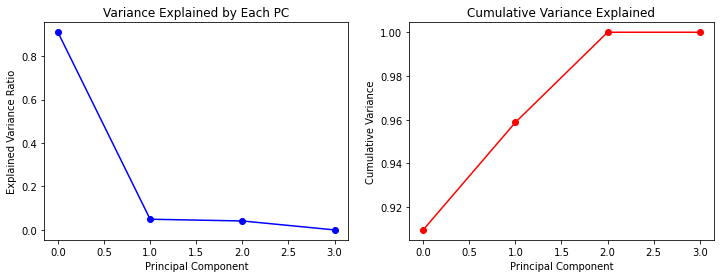

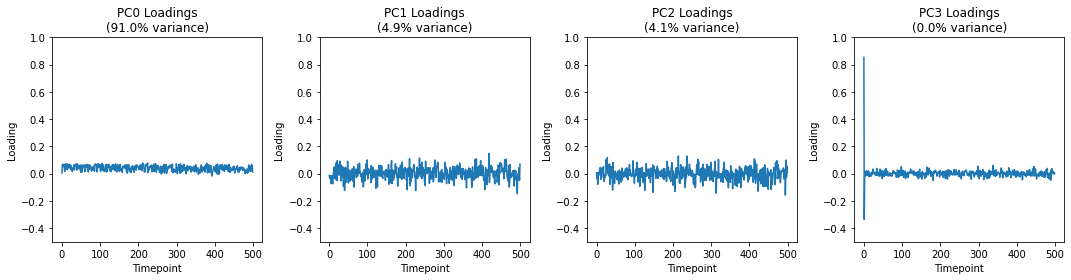

In [74]:
# 1. Plot explained variance
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(explained_variance_ratio[:10], 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance Explained by Each PC')

plt.subplot(1, 2, 2)
plt.plot(cumulative_variance[:10], 'ro-')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Variance Explained')
plt.show()

# 2. Examine the principal components (loadings)
# These show which timepoints contribute most to each PC
s,e,b = 0,4,1
plt.figure(figsize=(15, 4))
for i,v in enumerate(np.arange(s,e,b)):
    plt.subplot(1, (e-s), i+1)
    plt.plot(pca.components_[v])
    plt.title(f'PC{v} Loadings\n({explained_variance_ratio[v]*100:.1f}% variance)')
    plt.xlabel('Timepoint')
    plt.ylabel('Loading')
    plt.ylim(-0.5,1)
plt.tight_layout()
plt.show()

In [75]:
np.shape(pca.components_)

(4, 500)

Text(0, 0.5, 'PC2')

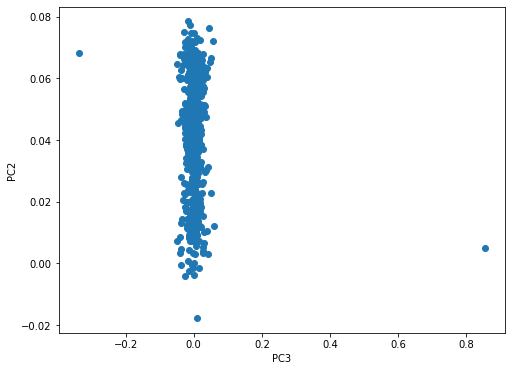

In [76]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot()

# Define the variables for the X, Y, and Z axes
x_data = pca.components_[3]
y_data = pca.components_[0]
# z_data = pca.components_[2]

# Create the 3D scatter plot
# You can use 'c' for color based on a variable, 'marker' for point style, etc.
ax.scatter(x_data, y_data, cmap='viridis', marker='o')

# Set axis labels
ax.set_xlabel('PC3')
ax.set_ylabel('PC2')
# ax.set_zlabel('PC3')

Text(0.5, 0, 'PC3')

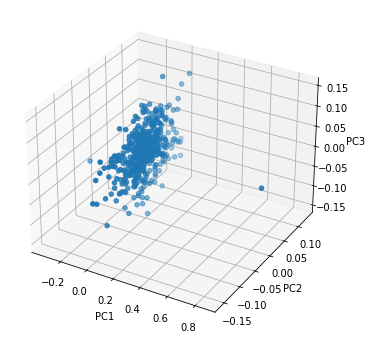

In [77]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Define the variables for the X, Y, and Z axes
x_data = pca.components_[3]
y_data = pca.components_[2]
z_data = pca.components_[1]

# Create the 3D scatter plot
# You can use 'c' for color based on a variable, 'marker' for point style, etc.
ax.scatter(x_data, y_data, z_data, cmap='viridis', marker='o')

# Set axis labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')


In [78]:
atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [79]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [80]:
full_res_PCA=[]
n_clusters=500
cluster_brain=pca.components_
# cluster_brain=cluster_variance.T
brain=cluster_brain
cluster_labels=giant_total_labels.T
n_tp = brain.shape[0]
# n_clusters = brain.shape[1]
brain_dims=[314,146,91]

colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]*brain_dims[2]))
colored_by_betas = brain[:, cluster_labels]  # Shape: (n_tp, n_voxels)
colored_by_betas = colored_by_betas.reshape(n_tp, brain_dims[0], brain_dims[1], brain_dims[2])
#     for cluster_num in range(n_clusters):
#         cluster_mask = cluster_labels==cluster_num
# #         print(np.shape(cluster_mask))
#         colored_by_betas[:,cluster_mask] = brain[:,cluster_num,np.newaxis]
colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1],brain_dims[2])
full_res_PCA=np.asarray(colored_by_betas)

In [81]:
cluster_variance=np.var(total,axis=0)

In [82]:
full_res_var=[]
n_clusters=500
cluster_brain=cluster_variance.T
brain=cluster_brain
cluster_labels=giant_total_labels.T
# n_tp = brain.shape[0]
# n_clusters = brain.shape[1]
brain_dims=[314,146,91]

colored_by_betas = np.zeros((brain_dims[0]*brain_dims[1]*brain_dims[2]))
colored_by_betas = brain[cluster_labels]  # Shape: (n_tp, n_voxels)
colored_by_betas = colored_by_betas.reshape(brain_dims[0], brain_dims[1], brain_dims[2])
#     for cluster_num in range(n_clusters):
#         cluster_mask = cluster_labels==cluster_num
# #         print(np.shape(cluster_mask))
#         colored_by_betas[:,cluster_mask] = brain[:,cluster_num,np.newaxis]
colored_by_betas = colored_by_betas.reshape(brain_dims[0],brain_dims[1],brain_dims[2])
full_res_var=np.asarray(colored_by_betas)

In [83]:
np.shape(full_res_PCA)

(4, 314, 146, 91)

In [84]:
total.shape

(4, 500)

In [85]:
brain=full_res_var
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = brain[:,:,::-1]
vmax = 1 #this was 0.5 for STA <------------
explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                    roi_masks,
                                                    roi_contours,
                                                    data_to_plot,
                                                    input_canvas,
                                                    vmax=vmax,
                                                    cmap='Greens', diverging=False)#'hot')

(-0.5, 499.5, 329.5, -0.5)

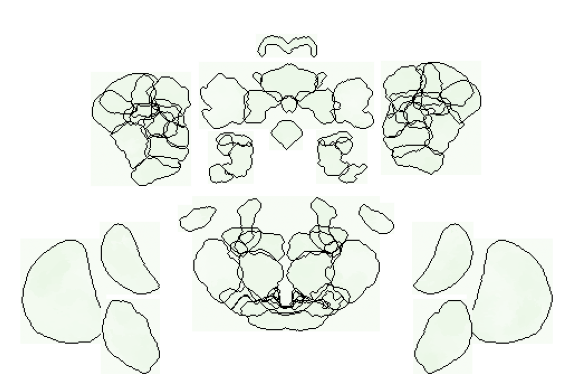

In [86]:
plt.subplots(figsize=(10,10))
brain=plt.imshow(explosion_map[170:,:]) #this was made with cmap=hot
plt.axis('off')
# plt.colorbar(brain)

In [87]:
corr_dict={}
for b in superclust_dict_z:
    corr_dict[b]={'before':[],'during':[], 'after':[]}
    for clust in superclust_dict_z[b]:
        corr_dict[b]['before'].append(np.mean(clust[:6]))
        corr_dict[b]['during'].append(np.mean(clust[12:18]))
        corr_dict[b]['after'].append(np.mean(clust[20:]))
    

In [88]:
# Step 1: Create initial DataFrame
rows = []
for behavior, periods in corr_dict.items():
    for i in range(len(periods['before'])):
        rows.append({
            'sample_id': i,
            'time_period': 'before',
            behavior: periods['before'][i]
        })
    for i in range(len(periods['during'])):
        rows.append({
            'sample_id': i,
            'time_period': 'during',
            behavior: periods['during'][i]
        })
    for i in range(len(periods['after'])):
        rows.append({
            'sample_id': i,
            'time_period': 'after',
            behavior: periods['after'][i]
        })

df = pd.DataFrame(rows)

# Step 2: Aggregate to get one row per (sample_id, time_period)
df_wide = df.groupby(['sample_id', 'time_period']).first().reset_index()
behavior_cols = list(corr_dict.keys())

In [89]:
correlation_matrix = df.corr()

<Figure size 576x432 with 0 Axes>

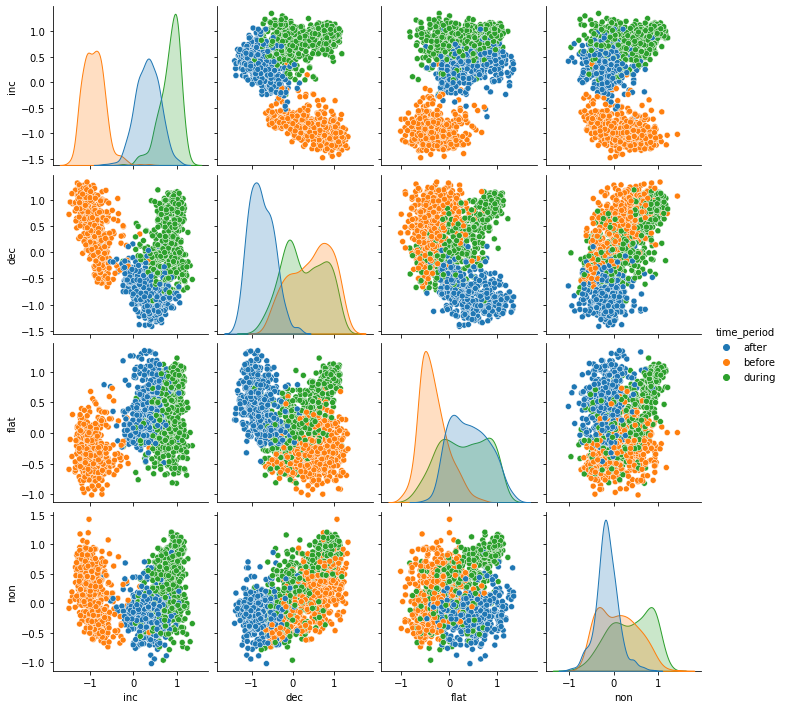

In [90]:
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.pairplot(df_wide,hue='time_period',vars=behavior_cols)
# plt.title('Correlation Heatmap')
plt.show()

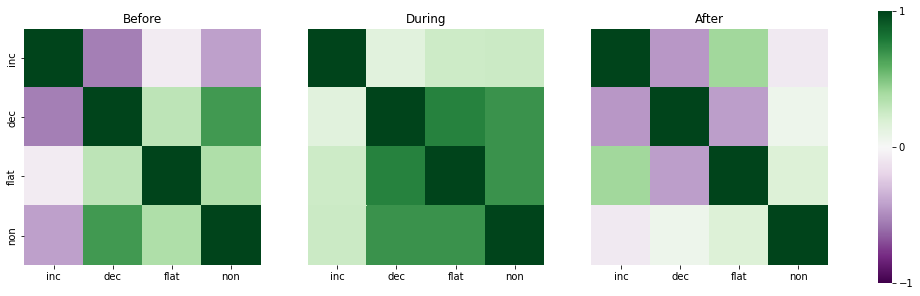

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, period in enumerate(['before', 'during', 'after']):
    # Filter data for this time period
    df_period = df_wide[df_wide['time_period'] == period]
    
    # Calculate correlation matrix for just the behaviors
    corr_matrix = df_period[behavior_cols].corr()
    # Plot heatmap
    sns.heatmap(corr_matrix, 
                annot=False,  # show correlation values
                cmap='PRGn',  # color scheme
                vmin=-1, vmax=1,  # correlation range
                center=0,  # center colormap at 0
                square=True,  # square cells
                ax=axes[idx], cbar=False, cbar_ax=None)
    if idx!=0:
        axes[idx].set_yticks([])
    axes[idx].set_title(f'{period.capitalize()}')
cbar=fig.colorbar(axes[2].collections[0], ax=axes, location='right');
cbar.outline.set_visible(False);
cbar.set_ticks([cbar.vmin, 0, cbar.vmax]) 
# plt.savefig(os.path.join(save_dir,f'tp_correlation.png'), dpi=300, bbox_inches='tight')